In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
import time
import warnings
warnings.filterwarnings('ignore')

import torch
from xrfm import xRFM
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, root_mean_squared_error
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

with open('processed/shuttle.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_full = data['X_train']
X_val_full   = data['X_val']
X_test       = data['X_test']
y_train_full = data['y_train']
y_val_full   = data['y_val']
y_test       = data['y_test']
n_classes    = data['n_classes']

print(f"n_train: {len(X_train_full)}, n_val: {len(X_val_full)}, n_test: {len(X_test)}")
print(f"Features: {X_train_full.shape[1]}, classes: {n_classes}")

SUBSAMPLE_SIZES = [2500, 5000, 10000, 20000, len(X_train_full)]
print(f"\nWill evaluate at n = {SUBSAMPLE_SIZES}")

Device: cuda
n_train: 37120, n_val: 9280, n_test: 11600
Features: 7, classes: 7

Will evaluate at n = [1000, 5000, 10000, 20000, 37120]


In [6]:
from sklearn.model_selection import train_test_split

def subsample_train(n_target, X_train_full, y_train_full, seed=RANDOM_SEED):
    """Return a stratified subsample of size n_target from the full train set."""
    if n_target >= len(X_train_full):
        return X_train_full, y_train_full
    X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=n_target,
        random_state=seed,
        stratify=y_train_full,
    )
    return X_sub, y_sub

for n in SUBSAMPLE_SIZES:
    Xs, ys = subsample_train(n, X_train_full, y_train_full)
    class_pct = (ys == 1).mean() * 100
    print(f"  n={n:6d} → shape {Xs.shape}, positive class pct: {class_pct:.1f}%")

  n=  1000 → shape (1000, 7), positive class pct: 0.1%
  n=  5000 → shape (5000, 7), positive class pct: 0.1%
  n= 10000 → shape (10000, 7), positive class pct: 0.1%
  n= 20000 → shape (20000, 7), positive class pct: 0.1%
  n= 37120 → shape (37120, 7), positive class pct: 0.1%


In [9]:
def train_and_eval_xrfm_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    """Train xRFM on a subsample of size n_train_target and return metrics + training time."""

    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    X_tr_t  = torch.tensor(X_tr,   dtype=torch.float32, device=DEVICE)
    X_val_t = torch.tensor(X_val,  dtype=torch.float32, device=DEVICE)
    X_te_t  = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

    # Pass integer labels directly — xRFM handles one-hot conversion internally
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long, device=DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)

    rfm_params = {
        'model': {
            'kernel': 'l2', 'bandwidth': 2.0, 'exponent': 1.4,
            'diag': False, 'bandwidth_mode': 'adaptive',
        },
        'fit': {
            'reg': 1e-2, 'iters': 10,
            'early_stop_rfm': False,
        },
    }

    from xrfm.rfm_src.gpu_utils import memory_scaling_factor as _gpu_scale
    import math
    _scale = _gpu_scale(DEVICE, quadratic=True)
    desired_leaf = max(4000, n_train_target // 4)
    max_leaf = math.ceil(desired_leaf / _scale) if _scale > 0 else desired_leaf

    model = xRFM(
        rfm_params=rfm_params,
        max_leaf_size=max_leaf,
        device=DEVICE,
        tuning_metric='accuracy',
        verbose=False,
    )

    t0 = time.perf_counter()
    model.fit(X_tr_t, y_tr_t, X_val_t, y_val_t)
    train_time = time.perf_counter() - t0

    y_pred_labels = model.predict(X_te_t)
    y_pred_proba  = model.predict_proba(X_te_t)

    if isinstance(y_pred_labels, torch.Tensor):
        y_pred_labels = y_pred_labels.cpu().numpy()
    if isinstance(y_pred_proba, torch.Tensor):
        y_pred_proba = y_pred_proba.cpu().numpy()

    acc = accuracy_score(y_test, y_pred_labels)

    labels = np.arange(n_classes)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    else:
        if y_pred_proba.shape[1] != n_classes:
            fixed = np.zeros((len(y_pred_proba), n_classes))
            fixed[:, :y_pred_proba.shape[1]] = y_pred_proba
            y_pred_proba = fixed / (fixed.sum(axis=1, keepdims=True) + 1e-12)
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr',
                            average='macro', labels=labels)

    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}


In [ ]:
def _expand_proba(proba, classes_seen, n_classes):
    """Map a (N, k) proba matrix from k seen classes back to (N, n_classes)."""
    full = np.zeros((len(proba), n_classes))
    for col, cls in enumerate(classes_seen):
        full[:, cls] = proba[:, col]
    return full


def _multiclass_auc(y_test, proba, n_classes):
    if n_classes == 2:
        return roc_auc_score(y_test, proba[:, 1])
    return roc_auc_score(y_test, proba, multi_class='ovr', average='macro',
                         labels=np.arange(n_classes))


def train_and_eval_xgb_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    # XGBoost requires consecutive labels [0, k) with no gaps.
    # Remap training labels to consecutive indices, then expand probas back out.
    classes_seen = np.unique(y_tr)
    label_map = {c: i for i, c in enumerate(classes_seen)}
    y_tr_mapped = np.array([label_map[c] for c in y_tr])
    k = len(classes_seen)

    kw = dict(
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        verbosity=0,
    )
    if k == 2:
        kw.update(objective='binary:logistic')
    else:
        kw.update(objective='multi:softprob', num_class=k)

    model = xgb.XGBClassifier(**kw)
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr_mapped, verbose=False)
    train_time = time.perf_counter() - t0

    proba = _expand_proba(model.predict_proba(X_test), classes_seen, n_classes)
    acc = accuracy_score(y_test, proba.argmax(axis=1))
    auc = _multiclass_auc(y_test, proba, n_classes)
    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}


def train_and_eval_rf_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    proba = _expand_proba(model.predict_proba(X_test), model.classes_, n_classes)
    acc = accuracy_score(y_test, proba.argmax(axis=1))
    auc = _multiclass_auc(y_test, proba, n_classes)
    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}


XGBoost & Random Forest scaling functions defined.


In [23]:
scaling_results = []

for n in SUBSAMPLE_SIZES:
    print(f"\n{'='*60}")
    print(f"n_train = {n}")
    print(f"{'='*60}")

    print("  xRFM...", end=" ", flush=True)
    try:
        r = train_and_eval_xrfm_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'xRFM', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

    print("  XGBoost...", end=" ", flush=True)
    try:
        r = train_and_eval_xgb_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'XGBoost', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

    print("  RandomForest...", end=" ", flush=True)
    try:
        r = train_and_eval_rf_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'RandomForest', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

scaling_df = pd.DataFrame(scaling_results)
scaling_df = scaling_df[['model', 'n_train', 'AUC-ROC', 'Accuracy', 'train_time_s']]
scaling_df.to_csv('results/tables/scaling_experiment.csv', index=False)

print(f"\n{'='*60}")
print(f"Saved: results/tables/scaling_experiment.csv ({len(scaling_df)} rows)")
print(scaling_df.to_string(index=False))


n_train = 2500
  xRFM... AUC=0.6807  time=0.8s
  XGBoost... AUC=0.8839  time=1.1s
  RandomForest... AUC=0.8105  time=0.4s

n_train = 5000
  xRFM... AUC=0.9848  time=1.3s
  XGBoost... AUC=0.9385  time=1.3s
  RandomForest... AUC=0.9088  time=0.5s

n_train = 10000
  xRFM... AUC=0.9471  time=2.8s
  XGBoost... AUC=0.9581  time=1.5s
  RandomForest... AUC=0.8831  time=0.5s

n_train = 20000
  xRFM... AUC=0.9504  time=8.6s
  XGBoost... AUC=0.9853  time=1.8s
  RandomForest... AUC=0.9118  time=0.6s

n_train = 37120
  xRFM... AUC=0.9840  time=20.3s
  XGBoost... AUC=0.9698  time=2.0s
  RandomForest... AUC=0.9140  time=0.9s

Saved: results/tables/scaling_experiment.csv (15 rows)
       model  n_train  AUC-ROC  Accuracy  train_time_s
        xRFM     2500 0.680722  0.995862      0.776026
     XGBoost     2500 0.883938  0.995603      1.075695
RandomForest     2500 0.810547  0.994914      0.433412
        xRFM     5000 0.984761  0.996810      1.272912
     XGBoost     5000 0.938504  0.996379      1.34

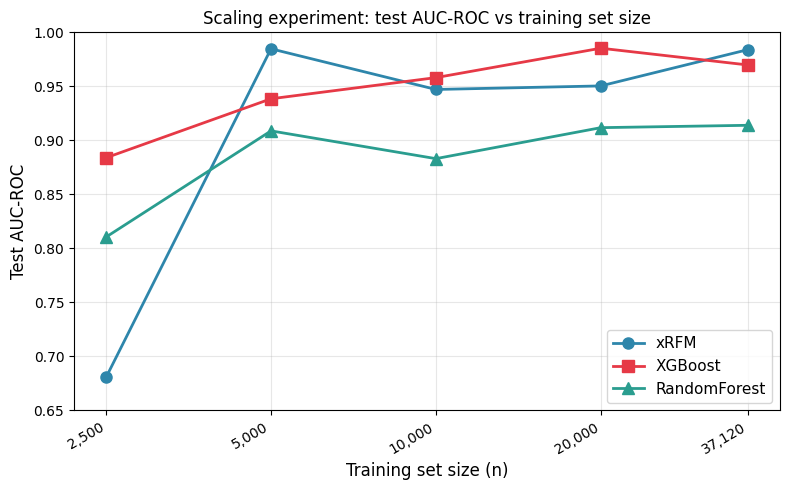

Saved: results/figures/scaling_performance.png


In [25]:
MODEL_ORDER = ['xRFM', 'XGBoost', 'RandomForest']
MODEL_COLORS = {'xRFM': '#2E86AB', 'XGBoost': '#E63946', 'RandomForest': '#2A9D8F'}
MODEL_MARKERS = {'xRFM': 'o', 'XGBoost': 's', 'RandomForest': '^'}

fig, ax = plt.subplots(figsize=(8, 5))

for model in MODEL_ORDER:
    sub = scaling_df[scaling_df['model'] == model].sort_values('n_train')
    ax.plot(sub['n_train'], sub['AUC-ROC'],
            marker=MODEL_MARKERS[model], color=MODEL_COLORS[model],
            linewidth=2, markersize=8, label=model)

ax.set_xlabel('Training set size (n)', fontsize=12)
ax.set_ylabel('Test AUC-ROC', fontsize=12)
ax.set_title('Scaling experiment: test AUC-ROC vs training set size',
             fontsize=12)
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0.65, 1.0)

x_ticks = sorted(scaling_df['n_train'].unique())
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{n:,}' for n in x_ticks], rotation=30, ha='right')
ax.xaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.savefig('results/figures/scaling_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/scaling_performance.png")

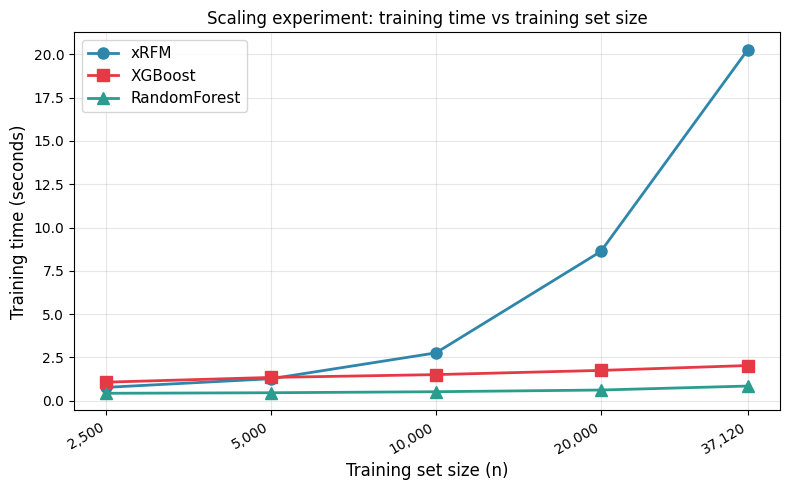

Saved: results/figures/scaling_training_time.png


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

for model in MODEL_ORDER:
    sub = scaling_df[scaling_df['model'] == model].sort_values('n_train')
    ax.plot(sub['n_train'], sub['train_time_s'],
            marker=MODEL_MARKERS[model], color=MODEL_COLORS[model],
            linewidth=2, markersize=8, label=model)

ax.set_xlabel('Training set size (n)', fontsize=12)
ax.set_ylabel('Training time (seconds)', fontsize=12)
ax.set_title('Scaling experiment: training time vs training set size',
             fontsize=12)
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

x_ticks = sorted(scaling_df['n_train'].unique())
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{n:,}' for n in x_ticks], rotation=30, ha='right')
ax.xaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.savefig('results/figures/scaling_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/scaling_training_time.png")